In [1]:
import os
import numpy as np 
from tqdm.notebook import tqdm, trange

In [2]:
import torch
from sbi import utils as Ut
from sbi import inference as Inference

In [3]:
import corner as DFM
# --- plotting --- 
import matplotlib as mpl
import matplotlib.pyplot as plt
#mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

# 1. Load noiseless training SED

In [4]:
dat_dir = '/scratch/network/chhahn/sedflow/training_sed/'

In [5]:
ibatch = 0 
wave = np.load(os.path.join(dat_dir, f'train.v0.1.{ibatch}.waves.npy'))
seds = np.load(os.path.join(dat_dir, f'train.v0.1.{ibatch}.seds.npy'))
zred = np.load(os.path.join(dat_dir, f'train.v0.1.{ibatch}.redshifts.npy'))
theta = np.load(os.path.join(dat_dir, f'train.v0.1.{ibatch}.thetas_sps.npy'))

In [6]:
# read in SDSS spectra
rawspec = np.load(os.path.join('/scratch/network/chhahn/sedflow/spectra/', 'sdss_spectra.100000.npz')) # SDSS dr16 spectra
w_sdss = 10**rawspec['wave']

In [7]:
wlim = (wave > w_sdss[0]) & (wave < w_sdss[-1])

(3784.426513671875, 9270.4306640625)

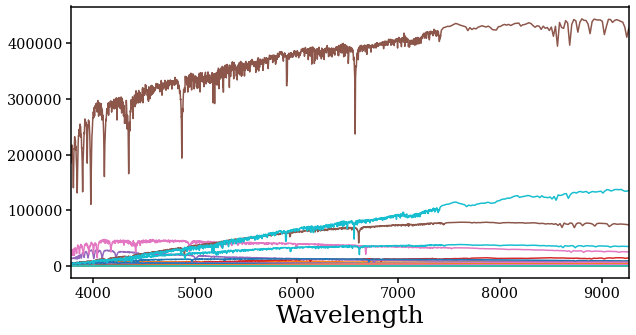

In [8]:
fig = plt.figure(figsize=(10,5))
sub = fig.add_subplot(111)
for i in range(100): 
    sub.plot(wave[100*i], seds[100*i])
sub.set_xlabel('Wavelength', fontsize=25)
sub.set_xlim(w_sdss[0], w_sdss[-1])

In [9]:
A_spec = np.array([np.median(sed[_w]) for sed, _w in zip(seds, wlim)])

# 2. assign ${\bf h}, A_{\rm ivar}$ using $q_\phi({\bf h}, A_{\rm ivar}\,|\,A_{\rm spec}, z)$

In [10]:
dat_dir = '/scratch/network/chhahn/sedflow/spectra/'
i_best = 6
h_ivar = np.load(os.path.join(dat_dir, f'ivar.vae_model.{i_best}.latvar.npy'))
A_ivar = np.load(os.path.join(dat_dir, f'ivar.vae_model.{i_best}.ivar_norm.npy'))
A_spec_vae = np.load(os.path.join(dat_dir, f'ivar.vae_model.{i_best}.spec_norm.npy'))
zred_vae = np.load(os.path.join(dat_dir, f'ivar.vae_model.{i_best}.zred.npy'))

N_train = 1000
y_train = np.concatenate([h_ivar, A_ivar], axis=1)[N_train:]
x_train = np.concatenate([np.log10(A_spec_vae.clip(1e-2, None)), zred_vae], axis=1)[N_train:]

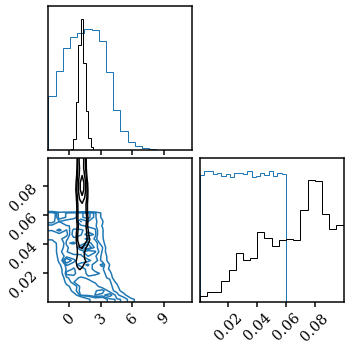

In [24]:
fig = DFM.corner(np.concatenate([np.log10(np.atleast_2d(A_spec).T.clip(1e-2, None)), np.atleast_2d(zred).T], axis=1), 
                plot_datapoints=False, plot_density=False, color='C0')
_ = DFM.corner(x_train,
               plot_datapoints=False, plot_density=False, fig=fig)

In [11]:
lower_bounds = torch.tensor([-4, -10, -7, -5, -16, 0]) 
upper_bounds = torch.tensor([10, 3.5, 7, 5, 5.5, 17])

prior = Ut.BoxUniform(low=lower_bounds, high=upper_bounds, device='cpu')

In [12]:
# load NDE
best_arch = '279x8'
nhidden, nblocks = 279, 8
fanpe = os.path.join(dat_dir, f'sdss_ivar.noise_nde.{best_arch}.pt')

anpe = Inference.SNPE(prior=prior, 
                      density_estimator=Ut.posterior_nn('maf', hidden_features=nhidden, num_transforms=nblocks), 
                      device='cpu')
# load ANPE
anpe.append_simulations(
    torch.as_tensor(y_train.astype(np.float32)), 
    torch.as_tensor(x_train.astype(np.float32)))

phat = anpe._build_neural_net(torch.as_tensor(y_train.astype(np.float32)), torch.as_tensor(x_train.astype(np.float32)))
phat.load_state_dict(torch.load(fanpe))

anpe._x_shape = Ut.x_shape_from_simulation(torch.as_tensor(y_train.astype(np.float32)))

best_phat = anpe.build_posterior(phat)

In [ ]:
# assign h, A_ivar
h_Aivar = []
for i in trange(len(zred)): 
    _y = best_phat.sample((1,), x=torch.as_tensor(np.array([np.log10(A_spec[i].clip(1e-2, None)), zred[i]]).flatten().astype(np.float32)).to('cpu'), show_progress_bars=False)
    h_Aivar.append(np.array(_y.detach().to('cpu')[0]))
h_Aivar = np.array(h_Aivar)

  0%|          | 0/100000 [00:00<?, ?it/s]

                        constant for `log_prob()`. However, only
                        1% posterior samples are within the
                        prior support. It may take a long time to collect the
                        remaining -96 samples.
                        Consider interrupting (Ctrl-C) and either basing the
                        estimate of the normalizing constant on fewer samples (by
                        calling `posterior.leakage_correction(x_o,
                        num_rejection_samples=N)`, where `N` is the number of
                        samples you want to base the
                        estimate on (default N=10000), or not estimating the
                        normalizing constant at all
                        (`log_prob(..., norm_posterior=False)`. The latter will
                        result in an unnormalized `log_prob()`.
                        constant for `log_prob()`. However, only
                        1% posterior samples are within

                        constant for `log_prob()`. However, only
                        1% posterior samples are within the
                        prior support. It may take a long time to collect the
                        remaining -91 samples.
                        Consider interrupting (Ctrl-C) and either basing the
                        estimate of the normalizing constant on fewer samples (by
                        calling `posterior.leakage_correction(x_o,
                        num_rejection_samples=N)`, where `N` is the number of
                        samples you want to base the
                        estimate on (default N=10000), or not estimating the
                        normalizing constant at all
                        (`log_prob(..., norm_posterior=False)`. The latter will
                        result in an unnormalized `log_prob()`.
                        constant for `log_prob()`. However, only
                        0% posterior samples are within

                        constant for `log_prob()`. However, only
                        1% posterior samples are within the
                        prior support. It may take a long time to collect the
                        remaining -75 samples.
                        Consider interrupting (Ctrl-C) and either basing the
                        estimate of the normalizing constant on fewer samples (by
                        calling `posterior.leakage_correction(x_o,
                        num_rejection_samples=N)`, where `N` is the number of
                        samples you want to base the
                        estimate on (default N=10000), or not estimating the
                        normalizing constant at all
                        (`log_prob(..., norm_posterior=False)`. The latter will
                        result in an unnormalized `log_prob()`.
                        constant for `log_prob()`. However, only
                        1% posterior samples are within

                        constant for `log_prob()`. However, only
                        1% posterior samples are within the
                        prior support. It may take a long time to collect the
                        remaining -74 samples.
                        Consider interrupting (Ctrl-C) and either basing the
                        estimate of the normalizing constant on fewer samples (by
                        calling `posterior.leakage_correction(x_o,
                        num_rejection_samples=N)`, where `N` is the number of
                        samples you want to base the
                        estimate on (default N=10000), or not estimating the
                        normalizing constant at all
                        (`log_prob(..., norm_posterior=False)`. The latter will
                        result in an unnormalized `log_prob()`.
                        constant for `log_prob()`. However, only
                        0% posterior samples are within

...

                        constant for `log_prob()`. However, only
                        1% posterior samples are within the
                        prior support. It may take a long time to collect the
                        remaining -68 samples.
                        Consider interrupting (Ctrl-C) and either basing the
                        estimate of the normalizing constant on fewer samples (by
                        calling `posterior.leakage_correction(x_o,
                        num_rejection_samples=N)`, where `N` is the number of
                        samples you want to base the
                        estimate on (default N=10000), or not estimating the
                        normalizing constant at all
                        (`log_prob(..., norm_posterior=False)`. The latter will
                        result in an unnormalized `log_prob()`.
                        constant for `log_prob()`. However, only
                        1% posterior samples are within

                        constant for `log_prob()`. However, only
                        1% posterior samples are within the
                        prior support. It may take a long time to collect the
                        remaining -71 samples.
                        Consider interrupting (Ctrl-C) and either basing the
                        estimate of the normalizing constant on fewer samples (by
                        calling `posterior.leakage_correction(x_o,
                        num_rejection_samples=N)`, where `N` is the number of
                        samples you want to base the
                        estimate on (default N=10000), or not estimating the
                        normalizing constant at all
                        (`log_prob(..., norm_posterior=False)`. The latter will
                        result in an unnormalized `log_prob()`.
                        constant for `log_prob()`. However, only
                        1% posterior samples are within

                        constant for `log_prob()`. However, only
                        1% posterior samples are within the
                        prior support. It may take a long time to collect the
                        remaining -87 samples.
                        Consider interrupting (Ctrl-C) and either basing the
                        estimate of the normalizing constant on fewer samples (by
                        calling `posterior.leakage_correction(x_o,
                        num_rejection_samples=N)`, where `N` is the number of
                        samples you want to base the
                        estimate on (default N=10000), or not estimating the
                        normalizing constant at all
                        (`log_prob(..., norm_posterior=False)`. The latter will
                        result in an unnormalized `log_prob()`.
                        constant for `log_prob()`. However, only
                        1% posterior samples are within

                        constant for `log_prob()`. However, only
                        1% posterior samples are within the
                        prior support. It may take a long time to collect the
                        remaining -96 samples.
                        Consider interrupting (Ctrl-C) and either basing the
                        estimate of the normalizing constant on fewer samples (by
                        calling `posterior.leakage_correction(x_o,
                        num_rejection_samples=N)`, where `N` is the number of
                        samples you want to base the
                        estimate on (default N=10000), or not estimating the
                        normalizing constant at all
                        (`log_prob(..., norm_posterior=False)`. The latter will
                        result in an unnormalized `log_prob()`.
                        constant for `log_prob()`. However, only
                        1% posterior samples are within

                        constant for `log_prob()`. However, only
                        1% posterior samples are within the
                        prior support. It may take a long time to collect the
                        remaining -67 samples.
                        Consider interrupting (Ctrl-C) and either basing the
                        estimate of the normalizing constant on fewer samples (by
                        calling `posterior.leakage_correction(x_o,
                        num_rejection_samples=N)`, where `N` is the number of
                        samples you want to base the
                        estimate on (default N=10000), or not estimating the
                        normalizing constant at all
                        (`log_prob(..., norm_posterior=False)`. The latter will
                        result in an unnormalized `log_prob()`.
                        constant for `log_prob()`. However, only
                        1% posterior samples are within

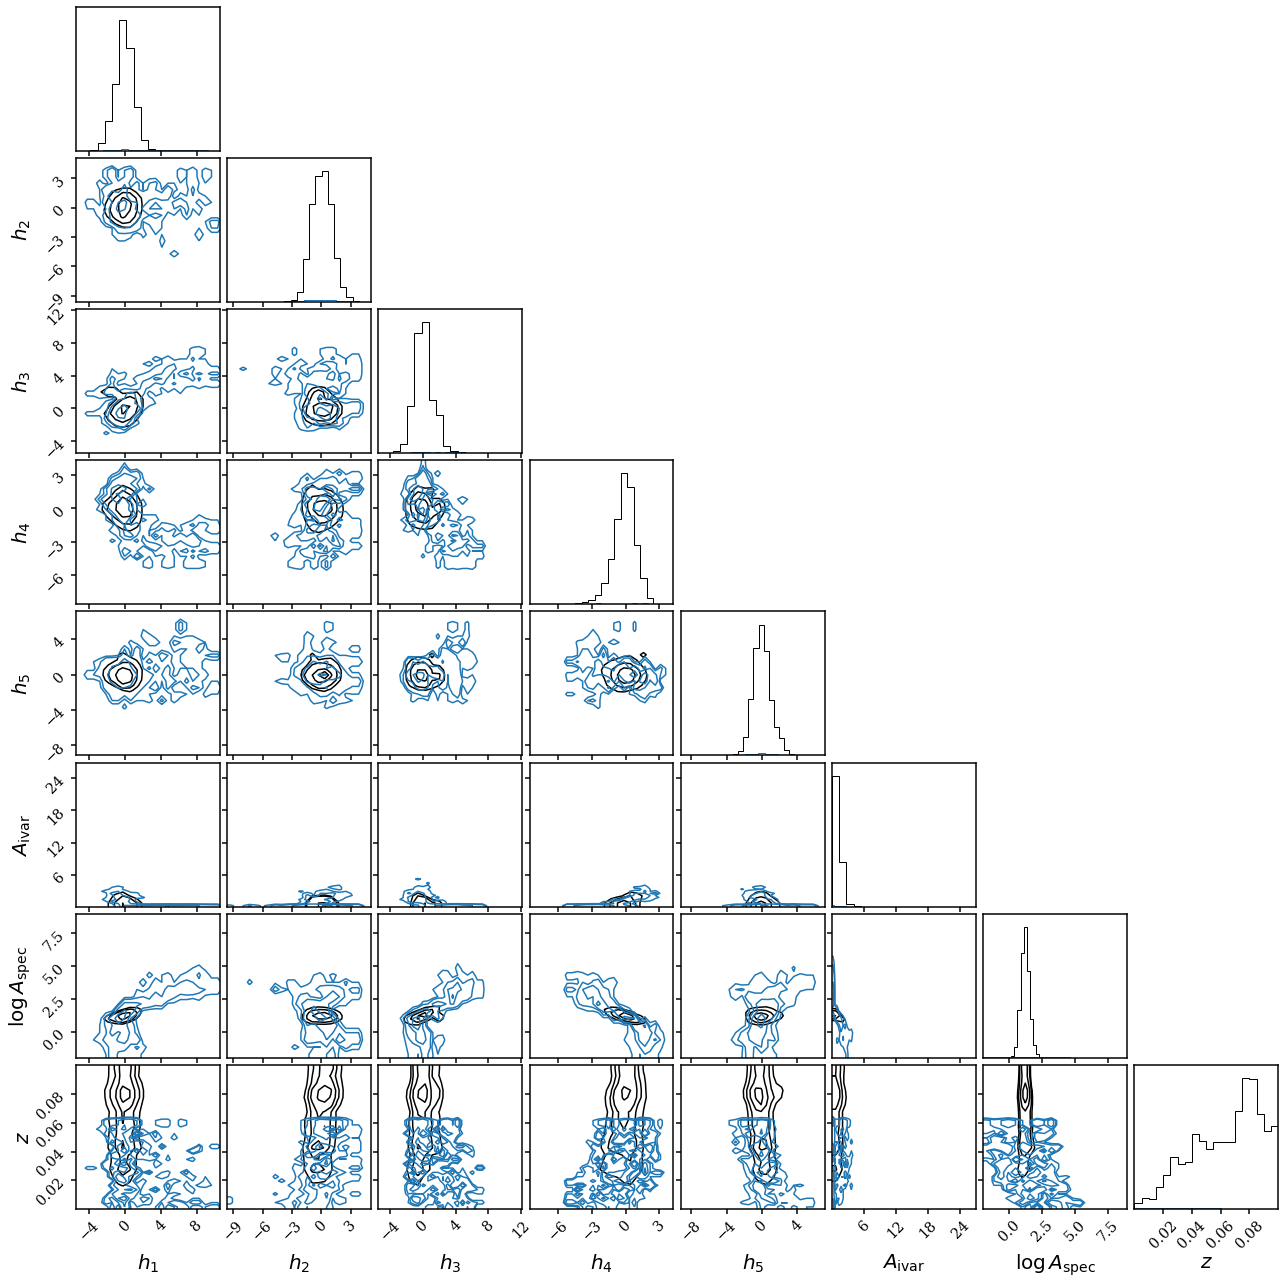

In [25]:
fig = DFM.corner(np.concatenate([y_train, x_train], axis=1),
                 plot_datapoints=False, plot_density=False, color='k')
_ = DFM.corner(np.concatenate([h_Aivar, np.atleast_2d(np.log10(A_spec[:1000].clip(1e-2, None))).T, np.atleast_2d(zred[:1000]).T], axis=1), 
               labels=[r'$h_1$', r'$h_2$', r'$h_3$', r'$h_4$', r'$h_5$', r'$A_{\rm ivar}$', r'$\log A_{\rm spec}$', r'$z$'], label_kwargs={"fontsize": 20},
               plot_datapoints=False, plot_density=False, color='C0', fig=fig)

# 3. Apply noise using the decoder

In [37]:
from torch import nn
from torch import optim
from torch.autograd import Variable
from torch.nn import functional as F

In [27]:
seed = 0 
cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if cuda else "cpu")

torch.manual_seed(seed)
if cuda:
    torch.cuda.manual_seed(seed)
    kwargs = {'num_workers': 4, 'pin_memory': True}
else:
    kwargs = {}

In [31]:
nwave = len(w_sdss)
avg_ivar = np.load(os.path.join(dat_dir, 'ivar.avg.npy'))
std_ivar = np.load(os.path.join(dat_dir, 'ivar.std.npy'))

In [29]:
class InfoVAE(nn.Module):
    def __init__(self, nwave=1000, ncode=5, alpha=0, lambd=10000, 
                 nkernels=[3, 3, 3], nhiddens_enc=[128, 64, 32], nhiddens_dec=[128, 64, 32], npools=[2, 2, 2], 
                 dropout=0.2):
        super(InfoVAE, self).__init__()
        
        self.ncode = int(ncode)
        self.alpha = float(alpha)
        self.lambd = float(lambd)

        nkernel0, nkernel1, nkernel2 = nkernels
        nhidden0_enc, nhidden1_enc, nhidden2_enc = nhiddens_enc
        nhidden0_dec, nhidden1_dec, nhidden2_dec = nhiddens_enc
        npool0, npool1, npool2 = npools

        # convolutional layers
        self.conv0 = nn.Conv1d(1, 1, kernel_size=nkernel0)
        Lout = nwave - nkernel0 + 1 
        self.p0 = nn.MaxPool1d(npool0)
        Lout = int((Lout - npool0)/npool0 + 1)
        self.conv1 = nn.Conv1d(1, 1, kernel_size=nkernel1)
        Lout = Lout - nkernel1 + 1 
        self.p1 = nn.MaxPool1d(npool1)
        Lout = int((Lout - npool1)/npool1 + 1)
        self.conv2 = nn.Conv1d(1, 1, kernel_size=nkernel2)
        Lout = Lout - nkernel2 + 1 
        self.p2 = nn.MaxPool1d(npool2)
        Lout = int((Lout - npool2)/npool2 + 1)

        # encoders
        self.enc0 = nn.Linear(Lout, nhidden0_enc)
        self.d1 = nn.Dropout(p=dropout)
        self.enc1 = nn.Linear(nhidden0_enc, nhidden1_enc)
        self.d2 = nn.Dropout(p=dropout)
        self.enc2 = nn.Linear(nhidden1_enc, nhidden2_enc)
        self.d3 = nn.Dropout(p=dropout)

        self.mu = nn.Linear(nhidden2_enc, ncode)
        self.lv = nn.Linear(nhidden2_enc, ncode)
        
        # decoders
        self.decd = nn.Linear(ncode, nhidden2_dec)
        self.d3 = nn.Dropout(p=dropout)
        self.decd2 = nn.Linear(nhidden2_dec, nhidden1_dec)
        self.d4 = nn.Dropout(p=dropout)
        self.decd3 = nn.Linear(nhidden1_dec, nhidden0_dec)
        self.d5 = nn.Dropout(p=dropout)
        self.outp = nn.Linear(nhidden0_dec, nwave)
        
    def encode(self, x):
        x = self.p0(F.relu(self.conv0(x)))
        x = self.p1(F.relu(self.conv1(x)))
        x = self.p2(F.relu(self.conv2(x)))
        x = self.d1(F.leaky_relu(self.enc0(x)))
        x = self.d2(F.leaky_relu(self.enc1(x)))
        x = self.d3(F.leaky_relu(self.enc2(x)))

        mu = self.mu(x)
        logvar = self.lv(x)
        return mu[:,0,:], logvar[:,0,:]
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return eps.mul(std).add_(mu)
    
    def decode(self, x):
        x = self.d3(F.leaky_relu(self.decd(x)))
        x = self.d4(F.leaky_relu(self.decd2(x)))
        x = self.d5(F.leaky_relu(self.decd3(x)))
        x = self.outp(x)
        return x
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar
    
    # https://ermongroup.github.io/blog/a-tutorial-on-mmd-variational-autoencoders/
    def compute_kernel(self, x, y):
        x_size = x.size(0)
        y_size = y.size(0)
        dim = x.size(1)
        x = x.unsqueeze(1) # (x_size, 1, dim)
        y = y.unsqueeze(0) # (1, y_size, dim)
        tiled_x = x.expand(x_size, y_size, dim)
        tiled_y = y.expand(x_size, y_size, dim)
        # The example code divides by (dim) here, making <kernel_input> ~ 1/dim
        # excluding (dim) makes <kernel_input> ~ 1
        kernel_input = (tiled_x - tiled_y).pow(2).mean(2)#/float(dim)
        return torch.exp(-kernel_input) # (x_size, y_size)
    
    # https://ermongroup.github.io/blog/a-tutorial-on-mmd-variational-autoencoders/
    def compute_mmd(self, x, y):
        xx_kernel = self.compute_kernel(x,x)
        yy_kernel = self.compute_kernel(y,y)
        xy_kernel = self.compute_kernel(x,y)
        return torch.mean(xx_kernel) + torch.mean(yy_kernel) - 2*torch.mean(xy_kernel)
    
    def loss(self, x, mask):
        recon_x, mu, logvar = self.forward(x)

        MSE = torch.sum(0.5 * ((x[:,0,:] - recon_x)[~mask]).pow(2))
        
        # KL divergence (Kingma and Welling, https://arxiv.org/abs/1312.6114, Appendix B)
        # 0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
        KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        #return MSE + self.beta*KLD, MSE
                
        # https://ermongroup.github.io/blog/a-tutorial-on-mmd-variational-autoencoders/
        device = x.device
        true_samples = Variable(torch.randn(200, self.ncode), requires_grad=False)
        true_samples = true_samples.to(device)

        z = self.reparameterize(mu, logvar) #duplicate call
        z = z.to(device)
        # compute MMD ~ 1, so upweight to match KLD which is ~ n_batch x n_code
        MMD = self.compute_mmd(true_samples,z) * x.size(0) * self.ncode
        return MSE + (1-self.alpha)*KLD + (self.lambd+self.alpha-1)*MMD, MSE, KLD, MMD

In [34]:
models, valid_losses = [], []
for i in range(10): 
    fmodel = os.path.join(dat_dir, f'ivar.vae_model.{i}.pt')
    state_dict = torch.load(fmodel) 
    
    model = InfoVAE(alpha=0, lambd=0, # these don't matter here
                    nwave=nwave,  
                    ncode=5, 
                    nkernels=[state_dict['conv0.weight'].shape[-1], state_dict['conv1.weight'].shape[-1], state_dict['conv2.weight'].shape[-1]],
                    nhiddens_enc=[state_dict['enc0.weight'].shape[0], state_dict['enc1.weight'].shape[0], state_dict['enc2.weight'].shape[0]], 
                    nhiddens_dec=[state_dict['decd.weight'].shape[0], state_dict['decd2.weight'].shape[0], state_dict['decd3.weight'].shape[0]], 
                    dropout=0)
    model.load_state_dict(torch.load(fmodel))
    models.append(model)

    floss = os.path.join(dat_dir, f'ivar.vae_model.{i}.loss.npy')
    valid_losses.append(np.load(floss)[:,1])

best model: ivar.vae_model.9.pt


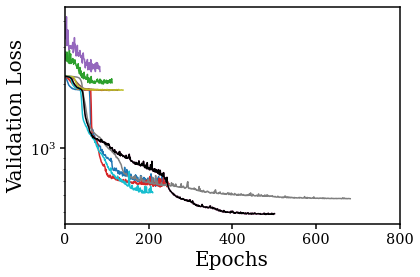

In [35]:
final_losses = np.array([_losses[-1] for _losses in valid_losses])
i_best = np.arange(len(final_losses))[np.isfinite(final_losses)][np.argmin(final_losses[np.isfinite(final_losses)])]
print(f'best model: ivar.vae_model.{i}.pt')

best_model = models[i_best]
best_model.to(device)

# plot validation losses
for _losses in valid_losses: 
    plt.plot(_losses)
plt.plot(valid_losses[i_best], c='k')
plt.yscale('log')
plt.xlabel('Epochs', fontsize=20)
plt.xlim(0, 800)
plt.ylabel('Validation Loss', fontsize=20)
plt.show()

In [38]:
w_ivar_recon = best_model.decode(torch.tensor(h_Aivar[:,:-1], dtype=torch.float32).to(device))

ivar_recon = (w_ivar_recon.detach().cpu().numpy() * std_ivar + avg_ivar) * h_Aivar[:,-1][:,None]

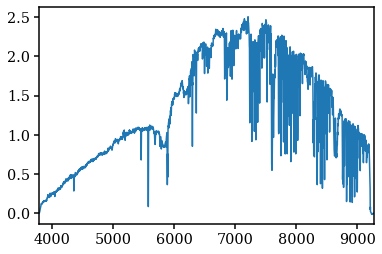

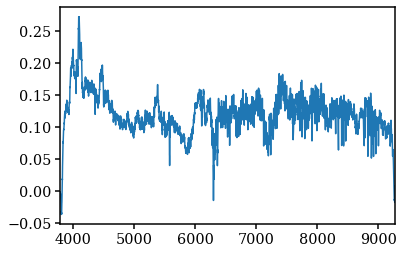

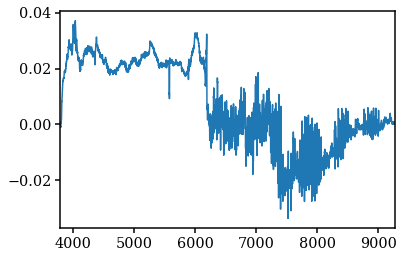

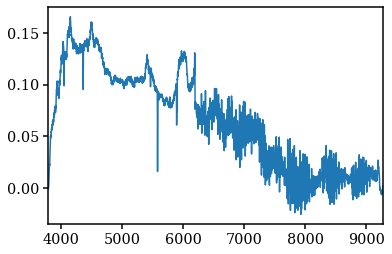

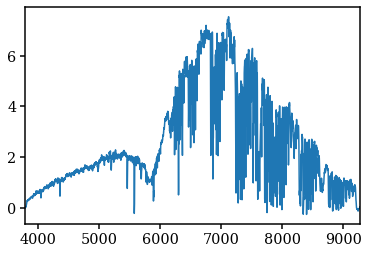

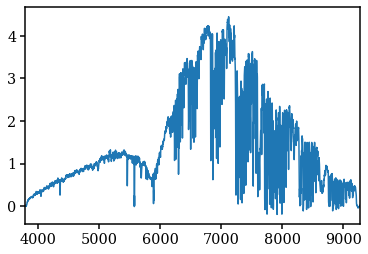

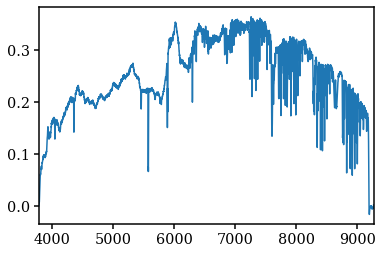

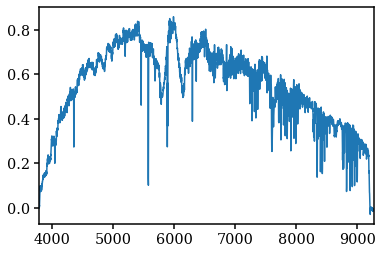

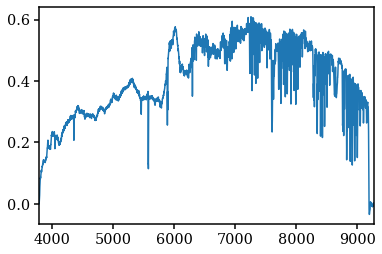

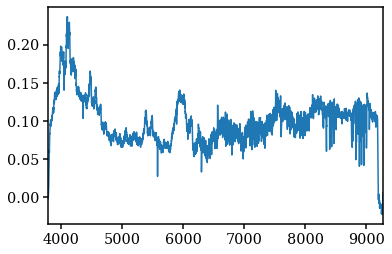

In [40]:
for _ivar in ivar_recon[::100]: 
    plt.plot(w_sdss, _ivar)
    plt.xlim(w_sdss[0], w_sdss[-1])
    plt.show()

# 5. Noisy SEDs

In [7]:
seds_noisy = np.load(os.path.join(dat_dir, f'train.v0.1.{ibatch}.seds.vae_noise.npy'))

(0.0, 120.0)

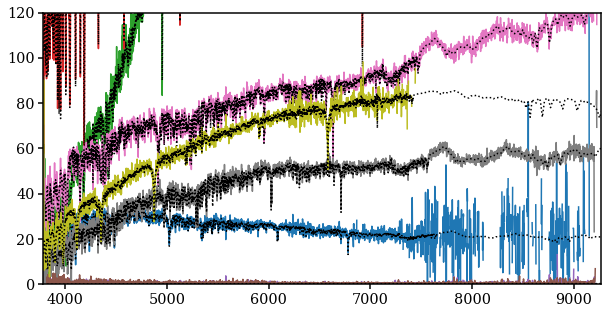

In [12]:
fig = plt.figure(figsize=(10,5))
sub = fig.add_subplot(111)
for i in range(10): 
    sub.plot(w_sdss, seds_noisy[100*i])
    sub.plot(wave[100*i], seds[100*i], c='k', ls=':')
sub.set_xlim(w_sdss[0], w_sdss[-1])
sub.set_ylim(0, 120)